#Villager Popularity and Attribute Patterns in Animal Crossing: New Horizons
by Kalin Swartz

This project analyzes villager attributes in the game, *Animal Crossing: New Horizons* to understand what drives their popularity in the community. By combining clustering, association rule mining, and statistical analysis, we uncover patterns in how traits interact and influence player preferences.

[Github: kalinswartz/datamining-ACNH](https://github.com/kalinswartz/datamining-ACNH)

# Introduction
In *Animal Crossing: New Horizons*, a life-simulation game where players build islands and live alongside unique animal villagers, some characters become global fan favorites, while others are almost forgotten.
What if that popularity isn't random at all... but driven by hidden patterns we can uncover?

Millions of players around the world form strong preferences for certain villagers. But no one really knows why some villagers rise to the top. Is it their personality? Their style? Or something deeper?



# Dataset Description and Setup

Dataset: **Animal Crossing New Horizons Catalog (Villagers)** from [Kaggle](https://www.google.com/url?q=https%3A%2F%2Fwww.kaggle.com%2Fdatasets%2Fjessicali9530%2Fanimal-crossing-new-horizons-nookplaza-dataset%2Fdata%3Fselect%3Dvillagers.csv)
* Size/structure: 30 different datasets, but focusing on the villagers.csv with 391 rows, and 17 columns with attributes for each villager
* Data types: mostly categorical: species, gender, personality, hobby, favorite song, color, etc; also list of furniture items, text (catchphrase), birthday

Also external popularity dataset: **Animal Crossing Portal Villager Popularity** from [Kaggle](https://www.kaggle.com/datasets/ampiiere/acnh-villager-popularity)
* Size/structure: 413 values, each representing a villager. Has a # tier and # rank column, with # tier ranging from 1-6 with 1 being the highest/most popular tier. # rank is numerical ranging anywhere from 1 to 163 (max) depending on how many villagers are in a specific tier.

We merge the two datasets, and also construct a **custom popularity score** combining tier and rank to create a continuous measure of popularity.

In [ ]:
# --- Initial data setup to merge datasets ---

import pandas as pd
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import itertools

# Hide repeats of DeprecationWarnings
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Get datasets and load into dataframe
path = kagglehub.dataset_download("jessicali9530/animal-crossing-new-horizons-nookplaza-dataset")
villagers = pd.read_csv(path + "/villagers.csv")

popularity_path = kagglehub.dataset_download("ampiiere/acnh-villager-popularity")
popularity = pd.read_csv(popularity_path + "/acnh_villager_data.csv")

#Lower column names on villagers.csv
villagers.columns = villagers.columns.str.lower()

# Villager names
villager_names = set(villagers['name'])
popularity_names = set(popularity['name'])

# Names in villagers but not in popularity
missing_in_popularity = villager_names - popularity_names
print("In villagers but not popularity:", missing_in_popularity)

# Names in popularity but not in villagers
missing_in_villagers = popularity_names - villager_names
print("In popularity but not villagers:", missing_in_villagers)

# Replace known differences manually
popularity['name'] = popularity['name'].replace({'Buck(Brows)': 'Buck', 'Crackle(Spork)' : 'Spork'})
villagers['name'] = villagers['name'].replace({'Renée' : 'Renee', "O'Hare" : 'OHare', 'Wart Jr.' : 'WartJr'})

# Merge datasets on villager name (adds tier and rank)
data = pd.merge(villagers, popularity, on='name', how='inner')

display(data)

# Convert popularity tier + rank into a single score
max_tier = data['tier'].max()
max_rank = data['rank'].max()

# weight so tier matters more than rank
W = max_rank + 1

data['popularity_score'] = (max_tier - data['tier'] + 1) * W + (max_rank - data['rank'] + 1)

data[['name','tier','rank','popularity_score']].head()

Using Colab cache for faster access to the 'animal-crossing-new-horizons-nookplaza-dataset' dataset.
Using Colab cache for faster access to the 'acnh-villager-popularity' dataset.
In villagers but not popularity: {"O'Hare", 'Buck', 'Renée', 'Wart Jr.', 'Spork'}
In popularity but not villagers: {'Chabwick', 'OHare', 'Faith', 'Sasha', 'Frett', 'Rilla', 'Quinn', 'Rio', 'Ione', 'Azalea', 'Ace', 'Renee', 'WartJr', 'Zoe', 'Petri', 'Cephalobot', 'Étoile', 'Chai', 'Buck(Brows)', 'Roswell', 'Crackle(Spork)', 'Marty', 'Chelsea', 'Marlo', 'Tiansheng', 'Shino', 'Toby'}


,name,species,gender,personality,hobby,birthday,catchphrase,favorite song,style 1,style 2,color 1,color 2,wallpaper,flooring,furniture list,filename,unique entry id,tier,rank
0,Admiral,Bird,Male,Cranky,Nature,27-Jan,aye aye,Steep Hill,Cool,Cool,Black,Blue,dirt-clod wall,tatami,717;1849;7047;2736;787;5970;3449;3622;3802;410...,brd06,B3RyfNEqwGmcccRC3,6,89
1,Agent S,Squirrel,Female,Peppy,Fitness,2-Jul,sidekick,Go K.K. Rider,Active,Simple,Blue,Black,concrete wall,colorful tile flooring,7845;7150;3468;4080;290;3971;3449;1708;4756;25...,squ05,SGMdki6dzpDZyXAw5,6,45
2,Agnes,Pig,Female,Big Sister,Play,21-Apr,snuffle,K.K. House,Simple,Elegant,Pink,White,gray molded-panel wall,arabesque flooring,4129;7236;7235;7802;896;3428;4027;7325;3958;71...,pig17,jzWCiDPm9MqtCfecP,4,26
3,Al,Gorilla,Male,Lazy,Fitness,18-Oct,ayyyeee,Go K.K. Rider,Active,Active,Red,White,concrete wall,green rubber flooring,1452;4078;4013;833;4116;3697;7845;3307;3946;39...,gor08,LBifxETQJGEaLhBjC,6,19
4,Alfonso,Alligator,Male,Lazy,Play,9-Jun,it'sa me,Forest Life,Simple,Simple,Red,Blue,yellow playroom wall,green honeycomb tile,4763;3205;3701;1557;3623;85;3208;3584;4761;121...,crd00,REpd8KxB8p9aGBRSE,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386,Winnie,Horse,Female,Peppy,Fashion,31-Jan,hay-OK,K.K. Country,Cool,Simple,White,Gray,backyard-fence wall,backyard lawn,1626;1626;5970;4003;3509;1620;1627;3467;1631;1...,hrs05,b4HwfyvThyipScSAv,5,86
387,Wolfgang,Wolf,Male,Cranky,Education,25-Nov,snarrrl,K.K. D&B,Cool,Active,Black,Green,dark wooden-mosaic wall,stripe flooring,4117;7323;7323;3275;4109;3270;3196;4338;3200;3...,wol02,RbF2wcn6jRxtgLDRd,3,15
388,Yuka,Koala,Female,Snooty,Fashion,20-Jul,tsk tsk,Soulful K.K.,Cool,Elegant,Orange,Yellow,beige art-deco wall,simple purple flooring,3957;3955;2554;3974;3951;794;4106;3959;3958;997,kal00,QDcxk3dCNT6yeD9hk,5,103
389,Zell,Deer,Male,Smug,Music,7-Jun,pronk,K.K. Swing,Cool,Gorgeous,Purple,Gray,cityscape wall,monochromatic tile flooring,1875;863;4129;4053;4053;3951;794;3775;4046;423...,der02,LodBWtdMRZbjFNga9,3,30


,name,tier,rank,popularity_score
0,Admiral,6,89,239
1,Agent S,6,45,283
2,Agnes,4,26,630
3,Al,6,19,309
4,Alfonso,6,6,322


# Research Questions
**RQ1: Which villager attributes are associated with high popularity, and are these relationships statistically significant?**

*   Data mining task type: Frequent Itemset / Association Rule Mining (course) and Statistical correlation and significance testing (external)
*   Relevant algorithm(s): Apriori (course), ANOVA (external), Spearman correlation (external), Chi-squared (external), Effect size (η², Cohen's d, Cramer's V)
*   Evaluation criteria: Support, confidence, lift, p-value, correlation coefficients (Spearman's rho), Effect size (external)

**RQ2: What clusters of villagers emerge based on their attributes (species, personality, hobby, styles), and do these clusters relate to popularity?**

*   Data mining task type: Clustering
*   Relevant algorithm(s): k-Means, Cosine similarity, Hierarchical clustering (course)
*   Evaluation criteria: Silhouette score, Davies-Bouldin index, Purity



# Motivation and Feasibility

We apply data mining techniques to understand what makes certain villagers more popular than others.

Instead of looking at single attributes, we focus on **combinations of traits**, since human preferences are often driven by multiple factors.

This motivates the use of:
- Clustering → to find natural villager groups
- Statistical tests → to validate relationships
- Association rules → to discover trait combinations linked to popularity

**RQ1 : Popularity Correlation with Attributes**

Motivation:
*   Some villager attributes may correlate strongly with popularity
*   Understanding this can provide insights to game design preferences and community favorites.

Non-triviality:

*   Simple averages or frequency counts ignore combinatorial patterns between multiple attributes
*   Statistical significance testing is needed to validate whether observed correlations are meaningful.

Feasibility:

*   Dataset is manageable: (only 391 villagers)
*   Popularity can be made numeric or put into bins, enabling ANOVA, Spearman correlation, and Chi-squared tests.
* Association rules are feasible if popularity is discretized or analyzed per-rule as mean values.

Risks:

*   Potentially too small sample size
*   Sparse attribute combinations - association rules may have low support
* If you bin popularity for rules, the choice of thresholds can affect the patterns discovered.

---

**RQ2 : Clustering Villagers for Similarity and Popularity Analysis**

Motivation:
*   Identify natural clusters of villagers based on attributes (personality, hobby, furniture, style).
* Clusters can suggest compatible roommate groups or archetypal groups for game analysis.
* Could lead to recommendation system for villagers - recommend similar villagers based on a liked villager.

Non-triviality:

*  Furniture vectors are high-dimensional and sparse → requires dimensionality reduction.
* Cosine similarity or Truncated SVD needed to preserve meaningful distances.

Feasibility:


*   Sparse matrix of furniture can be reduced via Truncated SVD or UMAP before clustering.
* Clustering algorithms (k-Means, hierarchical) scale well with ~400 villagers.

Risks:

*   High dimensionality / sparse furniture data
* Wrong choice of k in k-Means can lead to meaningless clusters
* Clusters may not map cleanly to intuitive “roommate compatibility” without careful dimensionality reduction or visualization.
* Cosine vs Euclidean vs other metrics may yield very different cluster results.
* Computational cost















# Exploratory Data Analysis

First, we conduct a simple EDA to see distributions of key categorical villager attributes - such as species, gender, personality, hobby, style 1 and 2. These provide good context for our further analysis and what trends exist in villager attributes already.

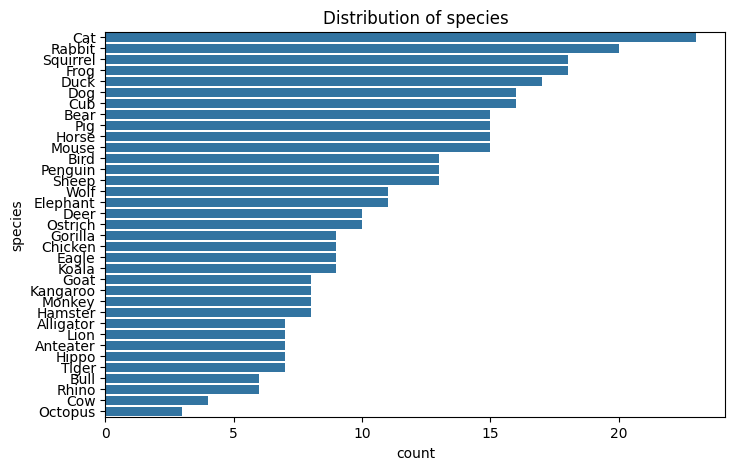

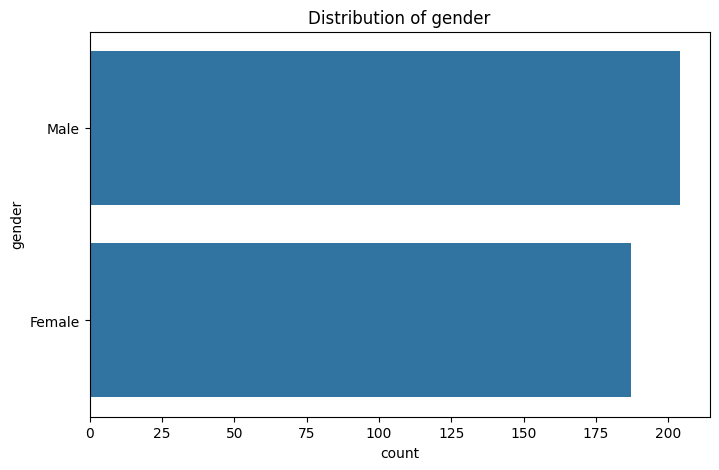

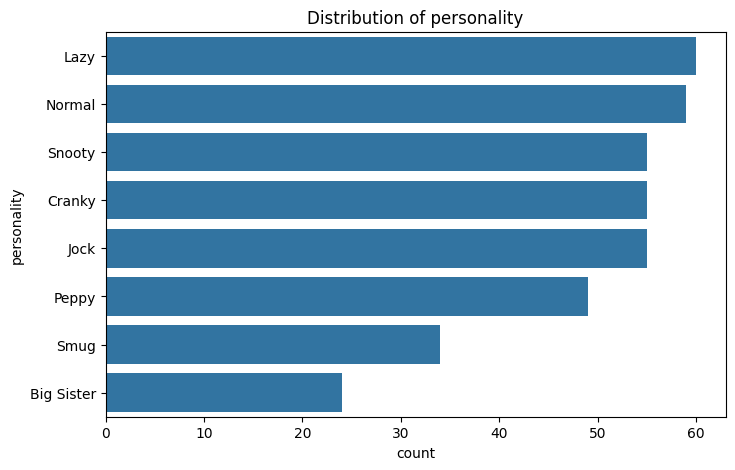

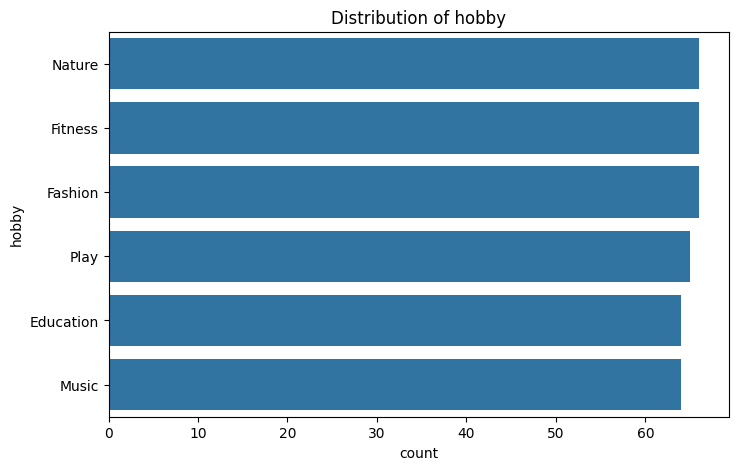

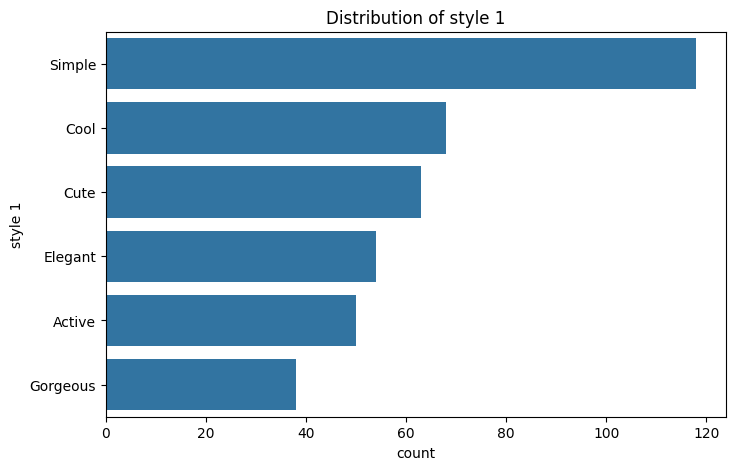

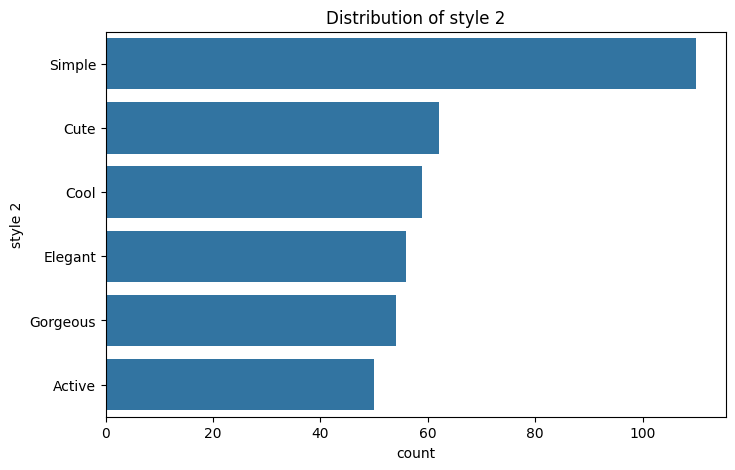

In [ ]:
# Get frequency of categorical items
categorical_cols_graph = ['species', 'gender', 'personality', 'hobby', 'style 1', 'style 2']

#Plot distributions of categorical items
for col in categorical_cols_graph:
    plt.figure(figsize=(8,5))
    sns.countplot(y=col, data=villagers, order=villagers[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.show()

#Clustering Villagers


##Preprocessing

We focus on key categorical features such as species, gender, personality, hobby, and styles. These features are one-hot encoded to transform them into a numerical format suitable for clustering. StandardScaler is used to normalize features so no category dominates due to scale.

We also apply dimensionality reduction to manage the high-dimensional feature space created by encoding.

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import TruncatedSVD

# Select key categorical features
features = [
    'species', 'gender', 'personality', 'hobby',
    'style 1', 'style 2'
]

df = data.dropna(subset=features).copy()

# One-hot encoding
encoder = OneHotEncoder(sparse_output=False)
X = encoder.fit_transform(df[features])

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dimensionality reduction: important for clustering
svd = TruncatedSVD(n_components=20, random_state=42)
X_reduced = svd.fit_transform(X_scaled)

## Choosing the Number of Clusters (k)

We use the silhouette score to evaluate k-Means clustering quality across different values of k. This helps us select a number of clusters that balances separation and cohesion. We can see that k=9 seems to have the best silhouette score, even though it is still overall very low at 0.18.

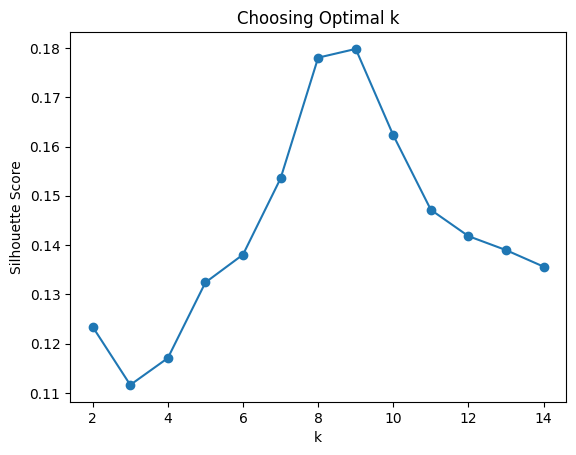

Best k: 9


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
k_values = range(2, 15)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_reduced)
    sil_scores.append(silhouette_score(X_reduced, labels))

plt.plot(k_values, sil_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Choosing Optimal k")
plt.show()

print("Best k:", k_values[sil_scores.index(max(sil_scores))])

## Clustering Villagers

Using the selected value of k=9, we apply K-Means to cluster villagers into groups based on their encoded attributes. This allows us to potentially identify villager "archetypes", for example:
- Cute villagers
- Sporty villagers
- Elegant villagers

These clusters represent groups of villagers with similar characteristics. We identify somewhat weak but interpretable groupings of villager attribute similarity.

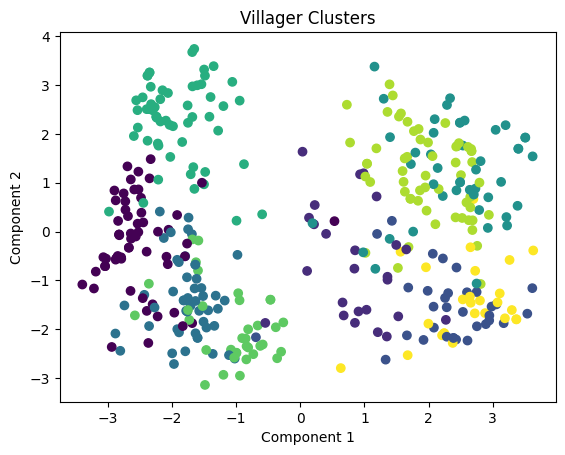

In [ ]:
k = k_values[sil_scores.index(max(sil_scores))]

kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(X_reduced)

df['cluster'].value_counts()

svd_2d = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd_2d.fit_transform(X_scaled)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df['cluster'])
plt.title("Villager Clusters")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

## Cluster Interpretation

We analyze the most common features in each cluster. It allows us interpret what each cluster represents in terms of villager traits. In particular, we can see the stand out difference between clusters is the personality trait.

In [ ]:
for i in range(k):
    print(f"\nCluster {i}")
    cluster_df = df[df['cluster'] == i]
    print(cluster_df[features].mode().iloc[0])


Cluster 0
species           Frog
gender            Male
personality       Jock
hobby          Fitness
style 1         Active
style 2         Simple
Name: 0, dtype: object

Cluster 1
species              Bear
gender             Female
personality    Big Sister
hobby               Music
style 1              Cool
style 2              Cool
Name: 0, dtype: object

Cluster 2
species        Anteater
gender           Female
personality      Snooty
hobby           Fashion
style 1         Elegant
style 2        Gorgeous
Name: 0, dtype: object

Cluster 3
species             Bear
gender              Male
personality       Cranky
hobby          Education
style 1             Cool
style 2           Simple
Name: 0, dtype: object

Cluster 4
species         Rabbit
gender          Female
personality      Peppy
hobby          Fashion
style 1           Cute
style 2           Cute
Name: 0, dtype: object

Cluster 5
species           Dog
gender           Male
personality      Lazy
hobby            Play
style

# Popularity Analysis
We convert the continuous popularity score into three categories: Low, Medium, and High. This allows us to analyze relationships between attributes and popularity using statistical tests like Chi-squared. It allows for comparison of high vs low popularity groups, and simplifies interpretation of relationships.



In [ ]:
df['popularity_bin'] = pd.qcut(
    df['popularity_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

display(df[['name','popularity_score','popularity_bin']].head())

,name,popularity_score,popularity_bin
0,Admiral,239,Low
1,Agent S,283,Low
2,Agnes,630,High
3,Al,309,Medium
4,Alfonso,322,Medium


## Attribute Significance Testing

We use Chi-squared tests to measure whether categorical attributes such as personality, species, hobby and gender are significantly associated with popularity levels.


We use Cramér's V to measure the strength of association between categorical villager attributes and popularity levels.
Unlike the Chi-Squared test, which only determines whether a relationship exists, Cramér's V quantifies the strength of that relationship on a scale from 0 (no association) to 1 (perfect association).
This allows us to compare which attributes (e.g., personality, species, hobby, gender) are most strongly associated with popularity.

In [ ]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()

    r, k = confusion_matrix.shape

    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

for col in ['personality', 'species', 'hobby', 'gender', 'style 1', 'style 2']:
    contingency = pd.crosstab(df[col], df['popularity_bin'])
    chi2, p, _, _ = chi2_contingency(contingency)
    v = cramers_v(contingency)
    print(f"{col}: p-value = {p:.4f}")
    print(f"{col}: Cramér's V = {v:.3f}")

personality: p-value = 0.0001
personality: Cramér's V = 0.235
species: p-value = 0.0000
species: Cramér's V = 0.450
hobby: p-value = 0.0010
hobby: Cramér's V = 0.195
gender: p-value = 0.0127
gender: Cramér's V = 0.149
style 1: p-value = 0.0066
style 1: Cramér's V = 0.177
style 2: p-value = 0.0000
style 2: Cramér's V = 0.223


From the statistical significance testing, we can see that a p value \< 0.05 shows it is statistically significant, therefore we can see that all these attributes are significantly associated with popularity levels. Furthermore, using Cramér's V, we can see the strength of associations between traits and popularity. We can see that species, followed by personality, style 2, hobby, style 1, then gender, is most strongly associated with popularity levels according to this metric.


## Association Rule Mining

Using the Apriori algorithm and association rules, we identify combinations of attributes that are strongly associated with high popularity. These rules reveal how multiple traits interact to influence outcomes.

We use **lift** as the primary metric for association rule evaluation because it measures how much more often a rule occurs compared to what would be expected if the variables were independent.

Unlike support or confidence, lift corrects for base rates, allowing us to identify truly meaningful relationships between villager attributes and high popularity.

A lift greater than 1 indicates a positive association, meaning the attribute combination appears with high popularity more often than expected by chance.

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

transactions = pd.get_dummies(df[features])
transactions['High_Popularity'] = (df['popularity_bin'] == 'High').astype(int)
transactions["Low_Popularity"] = (df["popularity_bin"] == "Low").astype(int)
transactions["Medium_Popularity"] = (df["popularity_bin"] == "Medium").astype(int)

frequent = apriori(transactions, min_support=0.03, use_colnames=True)
rules = association_rules(frequent, metric="lift", min_threshold=1.2)

popularity_targets = {
    "Low_Popularity",
    "Medium_Popularity",
    "High_Popularity"
}

rules = rules[
    rules["consequents"].apply(
        lambda x: len(popularity_targets.intersection(set(x))) > 0
    )
]

rules = rules.sort_values(by="lift", ascending=False)
display(rules)

# Sort specifically with species
species_rules = rules[
    rules["antecedents"].apply(lambda x: any("species" in item for item in x)) |
    rules["consequents"].apply(lambda x: any("species" in item for item in x))
]

display(species_rules.sort_values(by="lift", ascending=False).head(10))

# Sort specifically with low popularity
high_popularity_rules = rules[
    rules["antecedents"].apply(lambda x: any("High_Popularity" in item for item in x)) |
    rules["consequents"].apply(lambda x: any("High_Popularity" in item for item in x))
]
display(high_popularity_rules.sort_values(by="lift", ascending=False).head(10))

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1170,"(hobby_Nature, gender_Female)","(High_Popularity, personality_Normal)",0.069054,0.074169,0.035806,0.518519,6.991060,1.0,0.030684,1.922880,0.920526,0.333333,0.479947,0.500639
1844,"(gender_Male, hobby_Fitness, style 1_Active)","(Low_Popularity, personality_Jock)",0.066496,0.066496,0.030691,0.461538,6.940828,1.0,0.026269,1.733650,0.916895,0.300000,0.423182,0.461538
1854,"(gender_Male, style 1_Active)","(Low_Popularity, personality_Jock, hobby_Fitness)",0.102302,0.046036,0.030691,0.300000,6.516667,1.0,0.025981,1.362806,0.943020,0.260870,0.266220,0.483333
1912,"(gender_Male, personality_Lazy)","(Medium_Popularity, style 1_Simple, hobby_Play)",0.153453,0.035806,0.033248,0.216667,6.051190,1.0,0.027754,1.230886,0.986056,0.213115,0.187577,0.572619
1799,(personality_Lazy),"(Medium_Popularity, style 1_Simple, hobby_Play)",0.153453,0.035806,0.033248,0.216667,6.051190,1.0,0.027754,1.230886,0.986056,0.213115,0.187577,0.572619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1642,"(style 1_Simple, personality_Lazy)","(Low_Popularity, gender_Male)",0.125320,0.199488,0.030691,0.244898,1.227630,1.0,0.005691,1.060137,0.211988,0.104348,0.056726,0.199372
35,(gender_Female),(High_Popularity),0.478261,0.335038,0.194373,0.406417,1.213046,1.0,0.034138,1.120251,0.336623,0.314050,0.107343,0.493285
362,(hobby_Education),"(High_Popularity, gender_Female)",0.163683,0.194373,0.038363,0.234375,1.205798,1.0,0.006548,1.052247,0.204077,0.120000,0.049653,0.215872
794,"(gender_Male, style 1_Simple)",(Medium_Popularity),0.212276,0.329923,0.084399,0.397590,1.205099,1.0,0.014364,1.112327,0.216057,0.184358,0.100984,0.326702


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
7,(species_Pig),(Low_Popularity),0.038363,0.335038,0.030691,0.800000,2.387786,1.0,0.017837,3.324808,0.604388,0.089552,0.699231,0.445802
3,(species_Cat),(High_Popularity),0.058824,0.335038,0.040921,0.695652,2.076336,1.0,0.021213,2.184874,0.550781,0.115942,0.542308,0.408895


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1170,"(hobby_Nature, gender_Female)","(High_Popularity, personality_Normal)",0.069054,0.074169,0.035806,0.518519,6.991060,1.0,0.030684,1.922880,0.920526,0.333333,0.479947,0.500639
1174,(personality_Normal),"(High_Popularity, hobby_Nature, gender_Female)",0.150895,0.040921,0.035806,0.237288,5.798729,1.0,0.029631,1.257460,0.974613,0.229508,0.204746,0.556144
1257,(personality_Peppy),"(High_Popularity, hobby_Fashion, gender_Female)",0.125320,0.043478,0.030691,0.244898,5.632653,1.0,0.025242,1.266745,0.940302,0.222222,0.210575,0.475390
1251,"(personality_Peppy, gender_Female)","(High_Popularity, hobby_Fashion)",0.125320,0.043478,0.030691,0.244898,5.632653,1.0,0.025242,1.266745,0.940302,0.222222,0.210575,0.475390
995,(personality_Peppy),"(High_Popularity, hobby_Fashion)",0.125320,0.043478,0.030691,0.244898,5.632653,1.0,0.025242,1.266745,0.940302,0.222222,0.210575,0.475390
1146,(personality_Normal),"(High_Popularity, hobby_Education, gender_Female)",0.150895,0.038363,0.030691,0.203390,5.301695,1.0,0.024902,1.207161,0.955572,0.193548,0.171610,0.501695
1142,"(hobby_Education, gender_Female)","(High_Popularity, personality_Normal)",0.081841,0.074169,0.030691,0.375000,5.056034,1.0,0.024620,1.481330,0.873723,0.244898,0.324931,0.394397
1292,"(gender_Female, style 2_Cute)","(High_Popularity, personality_Peppy)",0.122762,0.058824,0.035806,0.291667,4.958333,1.0,0.028584,1.328720,0.910037,0.245614,0.247396,0.450181
1199,"(style 1_Simple, gender_Female)","(High_Popularity, personality_Normal)",0.089514,0.074169,0.030691,0.342857,4.622660,1.0,0.024051,1.408874,0.860721,0.230769,0.290213,0.378325
1276,"(style 1_Cute, gender_Female)","(High_Popularity, personality_Peppy)",0.161125,0.058824,0.040921,0.253968,4.317460,1.0,0.031443,1.261577,0.915968,0.228571,0.207341,0.474810


We can see that there are many "equations" that we can take away from these association rules in regards to villager popularity and their traits. We can change the min_support value to get more or less attributes per equation. This can help with further analysis, like seeing standalone attributes affects on popularity. Some examples of these equations are as follows:


*   Nature hobby + Female → Normal Personality + High Popularity
*   Male + Fitness hobby + Active style → Jock Personality + Low Popularity
* Simple + Cool → High Popularity
* Peppy → Female + High Popularity

From these different rules, we can see how personality, gender, and style dominate popularity levels. I was also curious on how species affects popularity, so I filtered the rules to ones containing species. We can see that Cats have high popularity and Pigs have low popularity. With the sparsity of species, they are rarer in association rules but still insightful. This is a support bias issue, since rare species categories are underrepresented in Apriori.



# Clusters vs Popularity Analysis

We analyze how popularity varies across clusters. We use ANOVA (Analysis of Variance) to compare popularity across clusters. It tests whether group means differ significantly and helps validate whether clustering is meaningful with respect to popularity. We can see below that the popularity levels do vary across clusters, which suggests that attributes do align with preference trends.

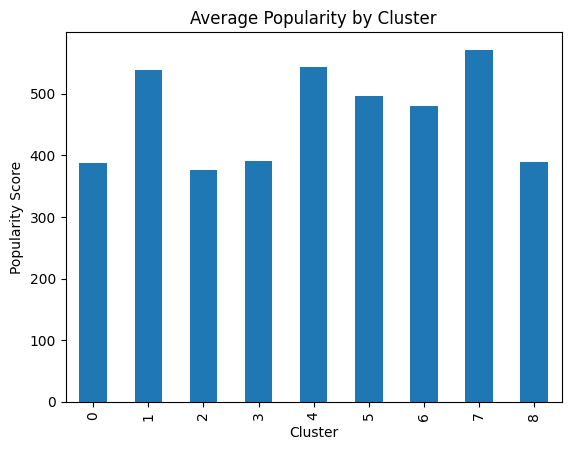

ANOVA p-value: 0.0000


In [ ]:
from scipy.stats import f_oneway

cluster_pop = df.groupby('cluster')['popularity_score'].mean()

cluster_pop.plot(kind='bar')
plt.title("Average Popularity by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Popularity Score")
plt.show()

groups = [df[df['cluster'] == i]['popularity_score'] for i in range(k)]
f_stat, p_val = f_oneway(*groups)

print(f"ANOVA p-value: {p_val:.4f}")

We can see that clusters 1, 4, and 7 are the most popular. These correspond with all female villagers, with personalities of Big Sister, Peppy, and Normal respectively. The most common styles in these clusters are Cute and Cool. Clusters 0, 2 and 3 have a lower mean popularity, and these correspond to Jock Male, Snooty Female and Cranky Male villagers. Medium popularity villagers are clusters 5 and 6, which are Lazy or Smug Male villagers. I can see how these patterns are also seen in the association rules.  

# Key Insights

- Popularity can be determined by single attributes, but also by combinations of traits.
- Clustering reveals meaningful villager archetypes
- Statistical tests confirm that these patterns are not due to random chance, and provide insight into the strength of association between popularity and attributes.
- Association rules highlight specific attribute combinations linked to high, medium, and low popularity levels.

# Applications
This project and analysis have practical implications:

- **Game Design:** Helps developers understand which villager traits are most appealing
- **Content Generation:** Guides creation of new villagers with desirable attribute combinations
- **Recommendation Systems:** Helps suggest villagers players are more likely to enjoy
- **User Preference Modeling:** General framework for understanding preference-driven systems

# Limitations

While this analysis reveals meaningful patterns in villager popularity and attributes, there are several important limitations to consider:

1. Dataset Size and Coverage - The dataset contains only 391 villagers, which limits statistical power. Some attribute combinations (e.g., specific species or rare personalities) occur infrequently, which can reduce the reliability of association rule mining and weaken detectable patterns. Furthermore, the current dataset is somewhat outdated so it is missing a few new villagers that may be very popular.

2. Popularity Dataset Bias - The popularity dataset used is only one source of popularity of villagers and therefore will not be able to capture other source's interpretations of popularity.

3. Feature Representation Limitations -
Some villager characteristics (e.g., aesthetic appeal, personality perception, or cultural preference) are subjective and not fully captured by structured dataset attributes.

4. Association Rule Sensitivity -
Association rule mining results are sensitive to hyperparameters such as minimum support and lift thresholds. Different parameter choices may lead to different discovered patterns.




# Conclusion

In this project, we explored whether villager popularity in *Animal Crossing: New Horizons* is driven by underlying attribute patterns rather than random player preference. By combining clustering, statistical hypothesis testing, and association rule mining, we were able to analyze both individual attributes and combinations of traits in relation to popularity.

The findings suggest that villager popularity is not purely random, but instead exhibits structured and statistically significant relationships with multiple attributes. Chi-squared tests and Cramér's V revealed that features such as species, personality, and style have meaningful associations with popularity levels, with species and personality showing the strongest effects. These results indicate that certain traits consistently align with higher or lower popularity across the dataset.

Clustering analysis further supported this conclusion by identifying interpretable, though moderately separated, groups of villagers based on shared attributes. While the clustering structure was relatively weak (as indicated by a low silhouette score), clear patterns still emerged. For example, clusters dominated by female villagers with "Cute" or "Cool" styles and personalities such as Peppy, Normal, or Big Sister tended to exhibit higher average popularity. In contrast, clusters characterized by traits such as Cranky or Jock personalities were generally associated with lower popularity. These findings suggest that combinations of traits—not just individual features—play an important role in shaping player preferences.

Association rule mining provided additional insight into how multiple attributes interact to influence popularity outcomes. The discovered rules highlighted recurring patterns, such as the alignment between certain styles and personality types with high popularity tiers. Importantly, these rules reinforce the idea that popularity is driven by multi-attribute interactions, rather than isolated features. However, due to the nature of the dataset and the assumptions of the Apriori algorithm, these rules should be interpreted as descriptive associations rather than causal relationships.

Overall, this analysis demonstrates that player preferences in *Animal Crossing: New Horizons* are influenced by identifiable and consistent attribute patterns, particularly those related to personality, style, and species. While the dataset size and methodological constraints limit the strength of causal claims, the combination of statistical validation and pattern discovery provides strong evidence that villager popularity follows meaningful trends.

# Resource Declaration

On my honor, I declare the following resources:
1. Collaborators:
- none

2. Web Sources:
- https://www.kaggle.com/datasets/jessicali9530/animal-crossing-new-horizons-nookplaza-dataset?select=villagers.csv
- https://www.kaggle.com/datasets/ampiiere/acnh-villager-popularity

3. AI Tools:
- ChatGPT: I gave it the dataset, my research questions and asked it to help implement the algorithm and pipeline. I asked questions about each implementation step on why or what it does if I was unsure. I also asked it for help on the wording for some sections.
- Google AI Search: For searching for various things I had questions about like checking definitions, p-value significance, etc.

4. Citations:

- none

